**Q1.What are the most common reasons for missing data in ETL pipelines?**

Some of the most common reasons for missing data in ETL pipelines are human error, system error, optional fields, and integration issues.

- Human errors: errors made while entering data are the most common reason for missing values. Such as typing errors, wrong entries, and missing entries.
- System error: It is another common reason; data may not get collected because of system errors, faulty sensors, or operational breakdowns
- Optional fields: When data is collected, some of the fields are kept optional; these fields may be blank or irrelevant, and this can also be a reason.
- Format/Integration issues: Other reasons can be format issues or encoding issues that can give missing values.


**Q2. Why is blindly deleting rows with missing values considered a bad practice in ETL?**

- Deleting rows blindly is considered a bad practice because it may impact the result if not carefully done and analysed before taking action. Deleting rows or columns can only be considered if it does not impact the outcome. For example, in case the data set is small, deleting rows will have a significant impact on the outcome; thus, deletion is not preferred, and it can only be done in a large data set if the missing values are less than 5% and do not have an impact on the outcome. Further, for columns, if the missing values are between 60-70%, it can be deleted if the column is not needed for aggregation or analysis.


**Q3. Explain the difference between: Also mention one scenario where each is appropriate.**

**Listwise deletion**
- Listwise deletion is generally referred to as row-wise deletion of data; if a cell contains missing values in a row, the entire row is deleted from the data set. Only to be done when the data set is large and missing values are less than 5%.
- For example, if a person during a survey skipped 5-6 questions out of 10, it's better to remove the entire row because data collected may not be conclusive.

**Column deletion**
- Under this, the entire column is deleted if it contains missing values and the percentage is between 60-70.
- For example, when collecting data in rural areas, most people don’t have an email address; there is a high chance that this column for most of the participants will remain empty, so this can be deleted.


**Q4. Why is median imputation preferred over mean imputation for skewed data such as income?**
- Median imputation is preferred over mean imputation for skewed data because the dataset will contain outliers; for instance, CEO salary will be much higher than a manager's, while a peon's salary will be very low. Compared to high-salary departments, the average salary will not reflect a correct picture. Median imputation is preferred for skewed data because it is resistant to outliers, while mean imputation can negatively impact the outcome by exaggerating the influence of extreme values.


**Q5. What is forward fill and in what type of dataset is it most useful?**
- Forward fill is a method to replace missing values in a data set, under which previous values are copied to the next value if it is null. For example, if the salary of the previous person was 18000 and the salary of the next person is missing, the 18000 will be copied and pasted in place of blank values.


**Q6. Why should flagging missing values be done before imputation in an ETL workflow?**
- Flagging should be done before imputation to ensure traceability; when making decisions, it is important to consider all data, including missing values. For example, it is important to understand whether the outcome before and after imputation has a significant difference or not to ensure credibility of decision-making.
- Flagging before imputation helps in understanding which values have been imputed and which were original. Another reason is control bias in data; it also provides a clear record for ETL pipelines, useful for compliance and debugging.


**Q7. Consider a scenario where income is missing for many customers. How can this missingness itself provide business insights?**
- In this case, it is important to understand the whole data; for example, verify if the missing income data is from a section of the group, such as students who don’t earn or unemployed people; this will make some sense why the data is missing.
- It is important to understand the reason for missing value that can be anything; for example, people with high net worth don't want to disclose their earnings for legal reasons. Thus, category and behaviour can be used as a matrix to understand the data.

**Q8. Listwise Deletion**

**Remove all rows where Region is missing.**

**Tasks:**

**1. Identify affected rows**

**2. Show the dataset after deletion**

**3. Mention how many records were lost**

**Answer: Code for SQL**
```
delete from sales2 where region is null;
```
**Affected Row**

Customer_ID 105

**After Deletion dataset**
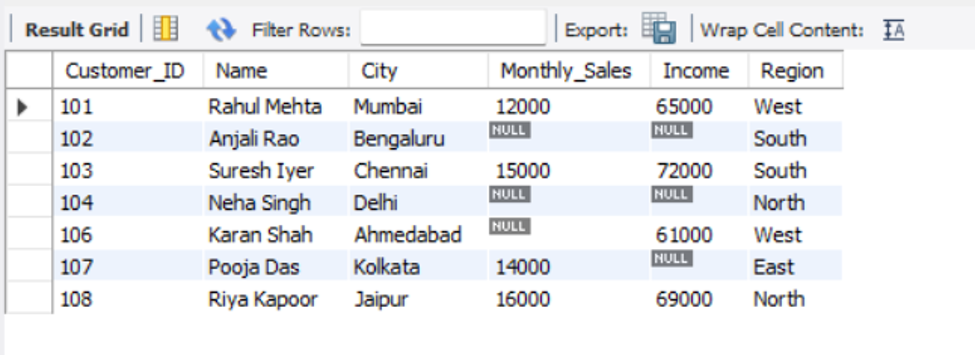

**Record Lost**

Only 1 Record Lost


**Q9. Imputation**

**Handle missing values in Monthly_Sales using:**

**Forward Fill**

**Tasks:**

**1. Apply forward fill**

**2. Show before vs after values**

**3. Explain why forward fill is suitable here**

**Answer**

**Code for forward fill application**
```
select *,
(select c2.monthly_sales from sales2 c2
where c2.customer_id <= c1.customer_id
and c2.monthly_sales is not null
order by c2.customer_id desc
limit 1) as monthly_sales_filled
from sales2 c1;
```
**Before**
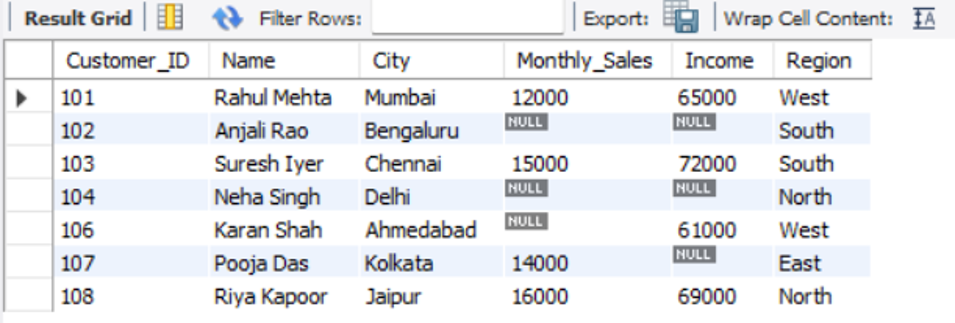

**After**
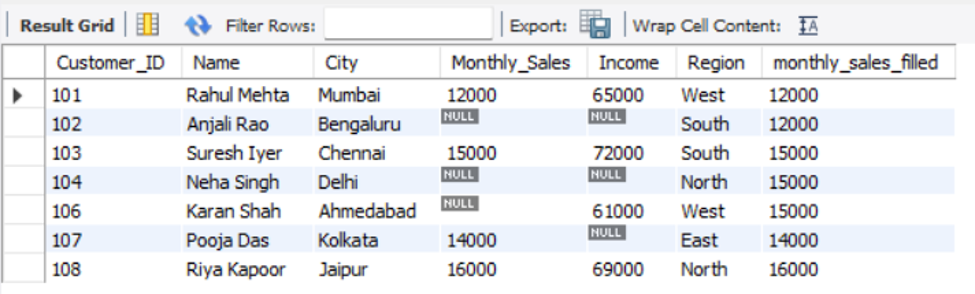


**Why it is suitable**
- Forward fill is suitable here because customers’ Monthly_Sales are logically sequential, so using the most recent known value is a reasonable estimate when a later row is missing data.


**Q10. Flagging Missing Data**

**Create a flag column for missing Income.**

**Tasks:**

**1. Create Income_Missing_Flag (0 = present, 1 = missing)**

**2. Show updated dataset**

**3. Count how many customers have missing income**

**Answer**

**Code for flagging**
```
select *,
case
when income is null then 1
else 0
end as income_missing_flag
from sales2;
```

**Updated Dataset**
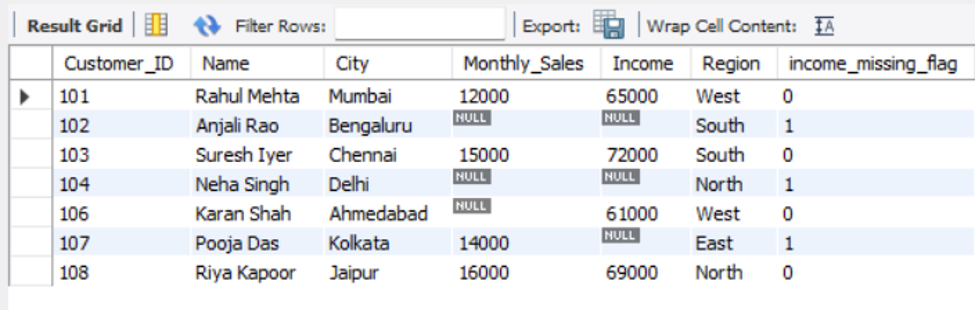

**Missing Income Count**
```
select count(*) as missing_income
from sales2
where income is null;
```
- Answer is 3
